In [73]:
import rasterio
from pathlib import Path

TILE_ID = "tile_-784_4522_p1"  # fill in actual tile_id

tile_dir = Path(f"../data/test_tiles/{TILE_ID}")  # fill in actual tile_id

tif_paths = sorted(tile_dir.glob("*/*.tif"))

print(f"{'file':40s} {'crs':25s} {'shape':12s} {'transform'}")
ref = None
for p in tif_paths:
    with rasterio.open(p) as src:
        info = (src.crs, (src.height, src.width), src.transform)
        rel = p.relative_to(tile_dir)
        print(f"{str(rel):40s} {str(info[0]):25s} {str(info[1]):12s} {info[2]}")
        if ref is None:
            ref = info
        else:
            same_crs = info[0] == ref[0]
            same_shape = info[1] == ref[1]
            same_transform = info[2].almost_equals(ref[2], precision=6)
            if not (same_crs and same_shape and same_transform):
                print(f"  !! MISALIGNED vs {tif_paths[0].relative_to(tile_dir)}: "
                      f"crs={same_crs} shape={same_shape} transform={same_transform}")

file                                     crs                       shape        transform
composites/s1s2_2017.tif                 EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2018.tif                 EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2019.tif                 EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2020.tif                 EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2017.tif                  EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2018.tif                  EPSG:6933                 (128, 128)   | 10.00, 0.00,-1003520.00|
| 0.00,-10.00, 5789440.00|
| 0.00

In [74]:
import ee
from config import settings
from gee.auth import get_ee_credentials
from tiling.grid import tile_geom
from registry.store import load_registry_entry

ee.Initialize(get_ee_credentials(), project=settings.gee_project)

tile = load_registry_entry(TILE_ID)  # match the exact tile_id from your plot titles
geom = tile_geom(tile)

for year in [2017, 2018, 2019, 2020]:
    n = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(geom)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
        .size()
        .getInfo()
    )
    print(year, n)

    n_prob = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterDate(f"{year}-01-01", f"{year}-12-31")
        .filterBounds(geom)
        .size()
        .getInfo()
    )
    print(year, "S2_SR:", n, "| CLOUD_PROBABILITY:", n_prob)

2017 9
2017 S2_SR: 9 | CLOUD_PROBABILITY: 268
2018 42
2018 S2_SR: 42 | CLOUD_PROBABILITY: 367
2019 16
2019 S2_SR: 16 | CLOUD_PROBABILITY: 367
2020 16
2020 S2_SR: 16 | CLOUD_PROBABILITY: 367


slope min/max/mean: 0.2630919 16.437159 3.9075055


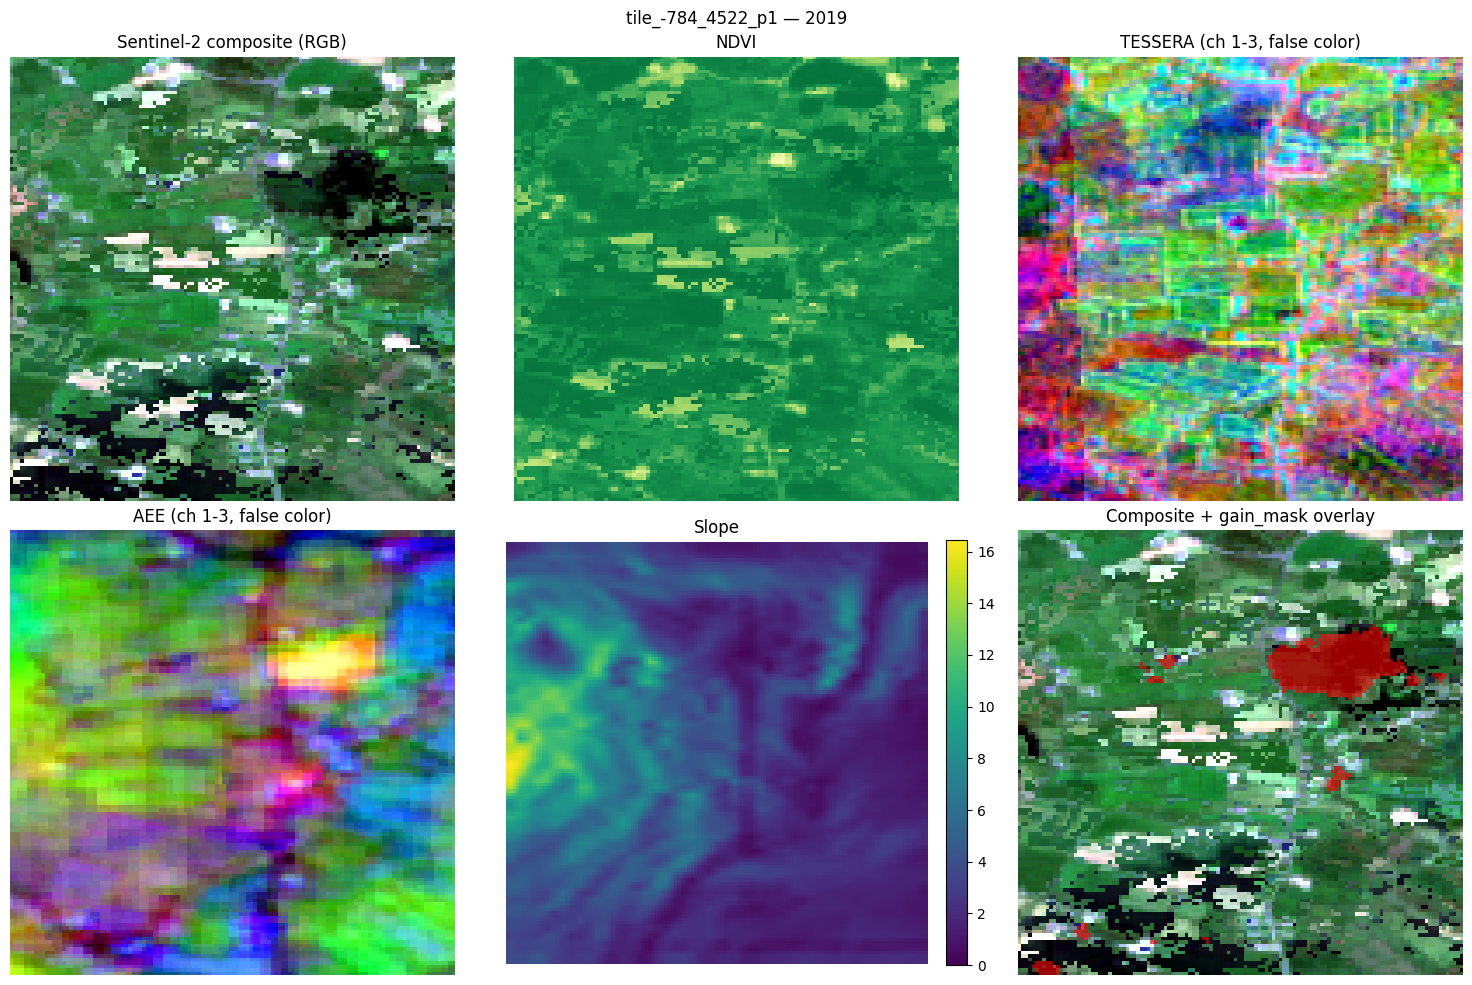

Pixel grid check: MATCH
fabdem min/max/mean: 6.43 92.34 33.177074


In [84]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

tile_id = tile_dir.name
year = 2019

def read(path, bands=None):
    with rasterio.open(path) as src:
        arr = src.read(bands) if bands else src.read()
        return arr, src.bounds, src.transform

def stretch(arr, low=2, high=98):
    """Per-band percentile stretch — arr is (H, W, bands)."""
    out = np.empty_like(arr, dtype="float32")
    for b in range(arr.shape[-1]):
        lo, hi = np.nanpercentile(arr[..., b], [low, high])
        out[..., b] = np.clip((arr[..., b] - lo) / (hi - lo), 0, 1)
    return out

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"{tile_id} — {year}")

# Composite: true-color from B4/B3/B2, stretched per-band (not one shared
# divisor across all three — that was washing out the color balance)
comp, comp_bounds, _ = read(tile_dir / "composites" / f"s1s2_{year}.tif", bands=[3, 2, 1])
rgb = stretch(comp.transpose(1, 2, 0))
axes[0, 0].imshow(rgb)
axes[0, 0].set_title("Sentinel-2 composite (RGB)")

# NDVI
ndvi, _, _ = read(tile_dir / "composites" / f"s1s2_{year}.tif", bands=[8])
axes[0, 1].imshow(ndvi[0], cmap="RdYlGn", vmin=-1, vmax=1)
axes[0, 1].set_title("NDVI")

# TESSERA embedding — per-band stretch
tess, _, tess_tf = read(tile_dir / "embeddings" / f"tessera_{year}.tif", bands=[1, 2, 3])
tess_rgb = stretch(tess.transpose(1, 2, 0))
axes[0, 2].imshow(tess_rgb)
axes[0, 2].set_title("TESSERA (ch 1-3, false color)")

# AEE embedding — per-band stretch
aee, _, aee_tf = read(tile_dir / "embeddings" / f"aee_{year}.tif", bands=[1, 2, 3])
aee_rgb = stretch(aee.transpose(1, 2, 0))
axes[1, 0].imshow(aee_rgb)
axes[1, 0].set_title("AEE (ch 1-3, false color)")

# Static: slope — explicit vmin/vmax + colorbar so a flat/low-slope tile
# doesn't just look like empty background under "terrain"
slope, _, _ = read(tile_dir / "static" / "slope.tif", bands=[1])
print("slope min/max/mean:", np.nanmin(slope), np.nanmax(slope), np.nanmean(slope))
im = axes[1, 1].imshow(slope[0], cmap="viridis", vmin=0, vmax=max(np.nanmax(slope), 1e-6))
fig.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)
axes[1, 1].set_title("Slope")

# Labels: gain_mask overlaid on composite RGB
gain, _, _ = read(tile_dir / "labels" / "gain_mask.tif", bands=[1])
axes[1, 2].imshow(rgb)
axes[1, 2].imshow(np.ma.masked_where(gain[0] == 0, gain[0]), cmap="autumn", alpha=0.6)
axes[1, 2].set_title("Composite + gain_mask overlay")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(
    "Pixel grid check:",
    "MATCH" if tess_tf.almost_equals(aee_tf, precision=6) else "MISMATCH between TESSERA and AEE transforms",
)

fabdem_arr, _, _ = read(tile_dir / "static" / "fabdem.tif", bands=[1])
print("fabdem min/max/mean:", np.nanmin(fabdem_arr), np.nanmax(fabdem_arr), np.nanmean(fabdem_arr))

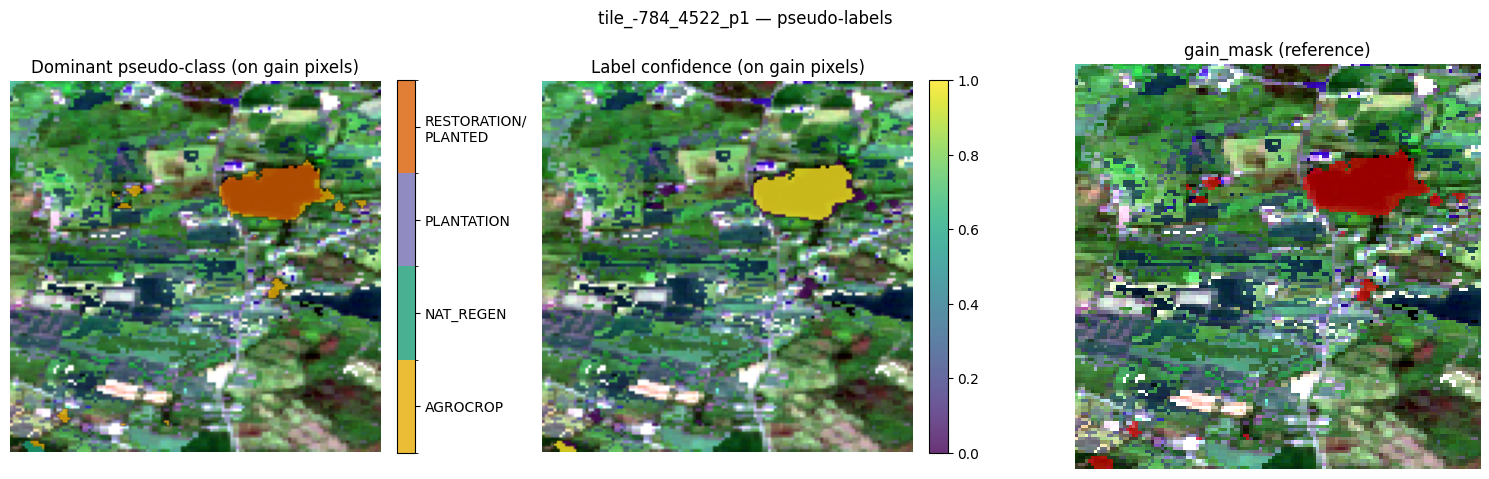

gain pixels: 665
gain percentage of tile: 4.06%
dominant_class values present (by % of gain pixels):
  RESTORATION/
PLANTED   475  ( 71.4%)
  AGROCROP               172  ( 25.9%)
  NAT_REGEN               18  (  2.7%)

mean confidence (all gain pixels): 0.741

Confidence histogram (all gain pixels):
  [0.0, 0.2):    172  ( 25.9%)
  [0.2, 0.4):      0  (  0.0%)
  [0.4, 0.6):      0  (  0.0%)
  [0.6, 0.8):      0  (  0.0%)
  [0.8, 1.0):    493  ( 74.1%)

Confidence histogram by class:
  AGROCROP               172      0      0      0      0
  NAT_REGEN                0      0      0      0     18
  RESTORATION/
PLANTED     0      0      0      0    475


In [77]:
from matplotlib.colors import ListedColormap, BoundaryNorm

LABEL_YEAR = 2020

pseudo, _, _ = read(tile_dir / "labels" / "pseudo_labels.tif")
dominant = pseudo[4]      # band 5: dominant_class
confidence = pseudo[5]    # band 6: label_confidence

class_names = ["AGROCROP", "NAT_REGEN", "PLANTATION", "RESTORATION/\nPLANTED"]
class_colors = ["#e6ab02", "#1b9e77", "#7570b3", "#d95f02"]
cmap = ListedColormap(class_colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle(f"{tile_id} — pseudo-labels")

comp_2020, comp_bounds_2020, _ = read(tile_dir / "composites" / f"s1s2_2020.tif", bands=[3, 2, 1])
rgb_2020 = stretch(comp_2020.transpose(1, 2, 0))

axes2[0].imshow(rgb_2020)
dom_masked = np.ma.masked_where(gain[0] == 0, dominant)
im0 = axes2[0].imshow(dom_masked, cmap=cmap, norm=norm, alpha=0.8)
axes2[0].set_title("Dominant pseudo-class (on gain pixels)")
cbar = fig2.colorbar(im0, ax=axes2[0], ticks=[0, 1, 2, 3], fraction=0.046, pad=0.04)
cbar.ax.set_yticklabels(class_names)

axes2[1].imshow(rgb_2020)
conf_masked = np.ma.masked_where(gain[0] == 0, confidence)
im1 = axes2[1].imshow(conf_masked, cmap="viridis", vmin=0, vmax=1, alpha=0.8)
axes2[1].set_title("Label confidence (on gain pixels)")
fig2.colorbar(im1, ax=axes2[1], fraction=0.046, pad=0.04)

axes2[2].imshow(rgb_2020)
axes2[2].imshow(np.ma.masked_where(gain[0] == 0, gain[0]), cmap="autumn", alpha=0.6)
axes2[2].set_title("gain_mask (reference)")

for ax in axes2:
    ax.axis("off")
plt.tight_layout()
plt.show()

n_gain = (gain[0] > 0).sum()
print(f"gain pixels: {n_gain}")
print(f"gain percentage of tile: {100 * n_gain / gain[0].size:.2f}%")

if n_gain > 0:
    gain_dominant = dominant[gain[0] > 0]
    gain_confidence = confidence[gain[0] > 0]

    print("dominant_class values present (by % of gain pixels):")
    counts = [(c, int((gain_dominant == c).sum())) for c in range(len(class_names))]
    counts = [(c, n) for c, n in counts if n > 0]
    for c, n in sorted(counts, key=lambda x: x[1], reverse=True):
        pct = 100 * n / n_gain
        print(f"  {class_names[c]:20s} {n:5d}  ({pct:5.1f}%)")

    print(f"\nmean confidence (all gain pixels): {np.nanmean(gain_confidence):.3f}")

    # confidence histogram — shows how much of the label set is low-confidence
    # "weight" (i.e. would get down-weighted or dropped by a confidence threshold)
    bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    hist, edges = np.histogram(gain_confidence[~np.isnan(gain_confidence)], bins=bins)
    print("\nConfidence histogram (all gain pixels):")
    for i in range(len(hist)):
        print(f"  [{edges[i]:.1f}, {edges[i+1]:.1f}): {hist[i]:6d}  ({100*hist[i]/n_gain:5.1f}%)")

    # same histogram broken out per class — useful for spotting which
    # classes are systematically low-confidence (candidates for relabeling
    # or a stricter per-class threshold rather than one global cutoff)
    print("\nConfidence histogram by class:")
    for c, name in enumerate(class_names):
        mask = gain_dominant == c
        n = int(mask.sum())
        if n == 0:
            continue
        conf_c = gain_confidence[mask]
        hist_c, _ = np.histogram(conf_c[~np.isnan(conf_c)], bins=bins)
        row = "  ".join(f"{h:5d}" for h in hist_c)
        print(f"  {name:20s} {row}")

In [78]:
import ee
from config import settings
from gee.auth import get_ee_credentials
from tiling.grid import tile_geom
from registry.store import load_registry_entry

ee.Initialize(get_ee_credentials(), project=settings.gee_project)

tile = load_registry_entry(TILE_ID)
if tile is None:
    raise ValueError(f"No registry entry for {TILE_ID}")

geom = tile_geom(tile)  # exact export geometry, EPSG:6933

print("EASE-Grid (meters):", tile["x_min_m"], tile["y_min_m"], tile["x_max_m"], tile["y_max_m"])
print("Lon/lat bbox:      ", tile["min_lon"], tile["min_lat"], tile["max_lon"], tile["max_lat"])

centroid = geom.centroid(maxError=1).coordinates().getInfo()
print("Centroid lon/lat:  ", centroid)

EASE-Grid (meters): -1003520.0 5788160.0 -1002240.0 5789440.0
Lon/lat bbox:       -10.40064968190828 52.15485264091512 -10.387383547109927 52.17107296809991
Centroid lon/lat:   [-10.394016614503698, 52.162962502442376]


In [ ]:
lon, lat = centroid
zoom = 15  # ~2.56km tile is comfortably visible around z14-16
url = f"https://code.earthengine.google.com/?lat={lat}&lon={lon}&zoom={zoom}"
print(url)

https://code.earthengine.google.com/?lat=52.162962502442376&lon=-10.394016614503698&zoom=15


In [80]:
import geemap
from export.composites import s2_composite

Map = geemap.Map(center=[lat, lon], zoom=15)
Map.addLayer(geom, {"color": "red"}, "tile boundary")

for year in settings.period_years:
    comp = s2_composite(geom, year)
    Map.addLayer(
        comp.select(["B4", "B3", "B2"]),
        {"min": 0, "max": 3000},
        f"S2 composite {year}",
    )

# Raw scenes for one year, so you can flip through individual acquisitions
# rather than only ever seeing the mosaic's final pick
raw_2017 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate("2017-01-01", "2017-12-31")
    .filterBounds(geom)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
)
print("2017 scene dates:", raw_2017.aggregate_array("system:time_start")
      .map(lambda t: ee.Date(t).format("YYYY-MM-dd")).getInfo())

Map

2017 scene dates: ['2017-06-18', '2017-07-23', '2017-09-11', '2017-09-21', '2017-09-21', '2017-10-11', '2017-10-11', '2017-11-30', '2017-11-30']


Map(center=[52.162962502442376, -10.394016614503698], controls=(WidgetControl(options=['position', 'transparen…